# Parte 1 — Exploratory Data Analysis (EDA) y calidad de datos

Este notebook sirve para inspeccionar `data/transactions_sample.csv` antes de consolidar la lógica final en `src/parte1_pandas.py`.

El objetivo no es hacer gráficos decorativos, sino encontrar problemas reales de calidad de datos, posibles fugas de información (*leakage*) y decisiones que deben quedar documentadas en `DECISIONS.md`, `ASSUMPTIONS.md` y `SELF_REVIEW.md`.

**Principio de trabajo:** antes de modelar o calcular KPIs, primero leo los datos, verifico tipos, formatos, nulos, duplicados, columnas sospechosas, outliers...

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

In [3]:
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent
DATA_PATH = PROJECT_ROOT / "data" / "transactions_sample.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path:    {DATA_PATH}")
print(f"File exists:  {DATA_PATH.exists()}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find data/transactions_sample.csv. "
        "Run this notebook from the project root or from the notebooks/ folder."
    )

Project root: C:\Users\Pep Biel\Documents\GitHub\getnet-ai-graduate-assessment
Data path:    C:\Users\Pep Biel\Documents\GitHub\getnet-ai-graduate-assessment\data\transactions_sample.csv
File exists:  True


## 1. Carga raw del dataset

Primero cargo el CSV sin intentar corregir tipos automáticamente. Quiero ver cómo vienen realmente las columnas y los datos antes de aplicar limpieza.

In [4]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")

display(df_raw.head(10))

Rows:    204,000
Columns: 13


,transaction_id,merchant_id,transaction_date,amount,status,channel,cancellation_reason,reference_date,fla_churn90,last_complaint_date,segment,mcc,dat_process
0,1,10007653,2025-09-11,"18,50",approved,pos,NaN,2025-09-30,0,NaN,SMB,4789,2025-09-11
1,2,10009541,2024-03-16,"16,81",approved,ecom,NaN,2025-09-30,0,2025-05-14,SMB,7995,2024-03-16
2,3,10006986,30/04/2024,"65,40",approved,tef,NaN,2025-09-30,0,NaN,SMB,5411,2024-04-30
3,4,10002926,2024-11-23,"86,97",denied,pos,NaN,2025-09-30,0,2025-06-12,SMB,7995,2024-11-23
4,5,10008646,2024-10-12,"484,62",approved,ecom,NaN,2025-09-30,0,NaN,Enterprise,5499,2024-10-12
5,6,10000405,2025-05-01,"214,56",approved,pos,NaN,2025-09-30,0,2025-03-17,MidMarket,7011,2025-05-01
6,7,10006263,2025-03-14,"98,74",approved,ecom,NaN,2025-09-30,0,2025-05-17,SMB,5812,2025-03-14
7,8,10006087,2025-03-26,"140,38",approved,pos,NaN,2025-09-30,0,2025-02-22,SMB,7995,2025-03-26
8,9,10002510,2024-10-18,"51,59",approved,pos,NaN,2025-09-30,0,NaN,SMB,5732,2024-10-18
9,10,10000386,2025-11-07,"20,17",approved,pos,NaN,2025-09-30,0,NaN,SMB,5732,2025-11-07


### Primera inspección del dataset

En una primera visualización del dataset se observan las siguientes columnas:

- `transaction_id`: identificador de la transacción.
- `merchant_id`: identificador del merchant/comercio.
- `transaction_date`: fecha en la que se produjo la transacción.
- `amount`: importe de la transacción. Aunque visualmente representa una cantidad monetaria, inicialmente revisaré su tipo y formato antes de usarlo en cálculos.
- `status`: estado de la transacción (`approved`, `denied`, `reversed`).
- `channel`: canal de la transacción (`pos`, `ecom`, `pix`, `tef`).
- `cancellation_reason`: motivo de cancelación. Presenta valores nulos que deberíamos tener en cuenta.
- `reference_date` representa el snapshot del análisis según la documentación. Lo interpreto como la fecha de corte a partir de la cual se etiqueta si un merchant churneó en los 90 días posteriores (`fla_churn90`). Por tanto, al construir señales para análisis o modelado, revisaré que las variables temporales no incorporen información posterior a este snapshot.
- `fla_churn90`: toma valor 1 si el merchant churneó en los 90 días posteriores a la fecha de referencia.
- `last_complaint_date`: fecha del último reclamo/queja. Presenta valores nulos y debe validarse.
- `segment`: segmento del merchant (`SMB`, `MidMarket`, `Enterprise`, etc.).
- `mcc`: código de categoría del merchant.
- `dat_process`: fecha de procesamiento del dato. No aparece en el apartado principal de “Dataset proporcionado” del `STATEMENT.md`, pero sí está presente en el CSV y aparece en el esquema SQL de la Parte 2.

A partir de esta primera visualización no tomo todavía decisiones definitivas, pero sí identifico varios puntos que conviene revisar:


1. `transaction_date` parece aparecer en más de un formato, por lo que comprobaré su distribución antes de parsearla.
2. `amount` debe revisarse antes de calcular KPIs, ya que podría estar almacenado como texto o usar separadores no compatibles directamente con `float`.
3. `cancellation_reason` y `last_complaint_date` tienen valores ausentes, por lo que revisaré si estos nulos son esperables, si afectan a muchas filas y si tienen alguna relación con otras columnas.
4. En las primeras filas visualizadas, `fla_churn90` aparece con valor 0. Esto solo es una observación inicial; revisaré la distribución completa antes de concluir si el target está balanceado o no.
5. `reference_date`, `last_complaint_date` y `fla_churn90` están relacionadas con una posible ventana temporal del problema, por lo que comprobaré la coherencia entre fechas antes de usar estas columnas en análisis posteriores.

**Siguiente paso:** cuantificar tipos, nulos, formatos de fecha, formato de importes, distribución del target y posibles duplicados antes de implementar la limpieza final en `src/parte1_pandas.py`.

## 2. Tipos de datos

Después de la primera visualización, reviso los tipos inferidos por pandas. Esto es importante porque algunas columnas que conceptualmente son fechas o importes pueden haberse cargado como texto.

In [5]:
dtypes_summary = (
    df_raw.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

display(dtypes_summary)

,column,dtype
0,transaction_id,int64
1,merchant_id,int64
2,transaction_date,object
3,amount,object
4,status,object
5,channel,object
6,cancellation_reason,object
7,reference_date,object
8,fla_churn90,int64
9,last_complaint_date,object


### Observación

Varias columnas se cargan como `object`, incluyendo columnas que conceptualmente deberían tratarse como fechas o importes (`transaction_date`, `amount`, `reference_date`, `last_complaint_date`, `dat_process`).

### Implicación

Antes de calcular KPIs o construir features, será necesario convertir explícitamente estas columnas. No conviene asumir que pandas ha interpretado correctamente los tipos.

## 3. Valores nulos

Reviso los valores ausentes por columna antes de decidir si imputar, descartar o conservarlos. No todos los nulos tienen el mismo significado: algunos pueden ser errores de datos y otros pueden ser esperables según la lógica del negocio.

In [6]:
missing_summary = (
    df_raw.isna()
    .sum()
    .rename("n_missing")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_summary["pct_missing"] = (
    missing_summary["n_missing"] / len(df_raw) * 100
).round(2)

missing_summary = missing_summary.sort_values("n_missing", ascending=False)

display(missing_summary)

,column,n_missing,pct_missing
6,cancellation_reason,190781,93.52
9,last_complaint_date,145548,71.35
3,amount,6087,2.98
0,transaction_id,0,0.00
1,merchant_id,0,0.00
2,transaction_date,0,0.00
4,status,0,0.00
5,channel,0,0.00
7,reference_date,0,0.00
8,fla_churn90,0,0.00


### Observación

Las columnas con valores ausentes son `cancellation_reason`, `last_complaint_date` y `amount`.

### Implicación

- En `amount`, los nulos afectan directamente al cálculo de TPV, por lo que deben reportarse como problema de calidad.
- En `cancellation_reason`, los nulos pueden ser esperables si no todas las transacciones/merchants tienen cancelación, pero conviene analizar su relación con `fla_churn90`.
- En `last_complaint_date`, los nulos pueden indicar que no hubo reclamos registrados, pero antes de usar esta columna hay que revisar su coherencia temporal con `reference_date`.

## 4. Cardinalidad de las columnas

Reviso cuántos valores únicos tiene cada columna. Esto ayuda a distinguir identificadores, variables categóricas, columnas casi constantes y posibles variables que no deberían usarse directamente como features.

In [7]:
cardinality = (
    df_raw.nunique(dropna=False)
    .rename("n_unique_including_na")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("n_unique_including_na", ascending=False)
)

display(cardinality)

,column,n_unique_including_na
0,transaction_id,204000
3,amount,45551
1,merchant_id,9982
2,transaction_date,1462
12,dat_process,731
9,last_complaint_date,440
11,mcc,10
6,cancellation_reason,8
5,channel,4
4,status,3


### Observación

`transaction_id` tiene una cardinalidad muy alta, como se espera de un identificador de transacción. `merchant_id` también tiene muchos valores únicos, ya que un merchant puede tener muchas transacciones. En cambio, columnas como `status`, `channel`, `segment` o `fla_churn90` tienen baja cardinalidad.

### Implicación

Los identificadores son útiles para agrupar o auditar, pero no deberían tratarse como variables numéricas ordinarias. Las columnas categóricas deberán normalizarse antes de calcular KPIs o entrenar modelos.

## 5. Distribución de `fla_churn90`

Reviso la distribución completa del target. En la primera visualización solo aparecían valores 0, pero eso no permite concluir si el target está balanceado o no.

Primero analizo la distribución a nivel de fila/transacción, porque es cómo aparece el dataset originalmente. Después reviso la distribución a nivel merchant, ya que `fla_churn90` representa si un merchant churneó en una ventana de 90 días.

,count,pct
fla_churn90,,
0,189637,92.96
1,14363,7.04


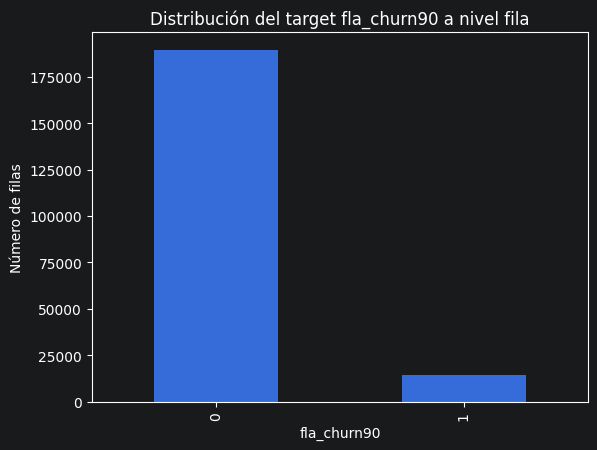

In [8]:
# Distribución del target a nivel fila/transacción
target_counts = df_raw["fla_churn90"].value_counts(dropna=False).sort_index()
target_pct = (target_counts / len(df_raw) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct,
})

display(target_summary)

ax = target_counts.plot(kind="bar")
ax.set_title("Distribución del target fla_churn90 a nivel fila")
ax.set_xlabel("fla_churn90")
ax.set_ylabel("Número de filas")
plt.show()

Merchants con más de un valor distinto de fla_churn90: 0


,count,pct
fla_churn90,,
0,9109,91.25
1,873,8.75


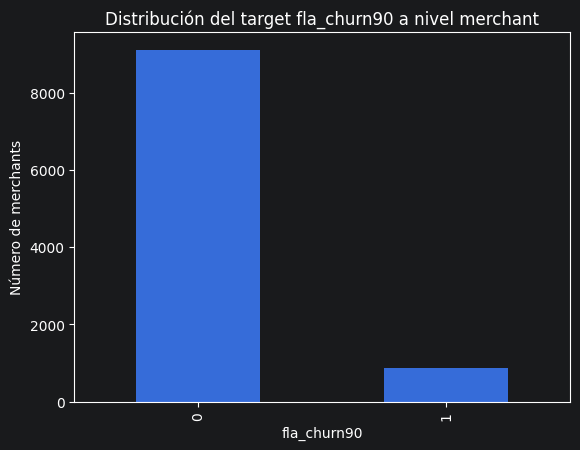

In [9]:
# Validación de consistencia del target dentro de cada merchant
target_consistency = (
    df_raw
    .groupby("merchant_id")["fla_churn90"]
    .nunique()
    .rename("n_unique_target_values")
)

n_inconsistent_merchants = (target_consistency > 1).sum()

print(f"Merchants con más de un valor distinto de fla_churn90: {n_inconsistent_merchants:,}")

# Distribución del target a nivel merchant
merchant_target = (
    df_raw
    .groupby("merchant_id")["fla_churn90"]
    .first()
)

merchant_target_counts = merchant_target.value_counts(dropna=False).sort_index()
merchant_target_pct = (merchant_target_counts / len(merchant_target) * 100).round(2)

merchant_target_summary = pd.DataFrame({
    "count": merchant_target_counts,
    "pct": merchant_target_pct,
})

display(merchant_target_summary)

ax = merchant_target_counts.plot(kind="bar")
ax.set_title("Distribución del target fla_churn90 a nivel merchant")
ax.set_xlabel("fla_churn90")
ax.set_ylabel("Número de merchants")
plt.show()

### Observación

`fla_churn90` está desbalanceado tanto a nivel fila como a nivel merchant: la mayoría de observaciones pertenecen a la clase 0 y una minoría a la clase 1.

Además, reviso la consistencia del target dentro de cada `merchant_id`. Esta comprobación es importante porque el dataset está a nivel transacción, pero el churn se interpreta a nivel merchant. Si un mismo merchant tuviera valores distintos de `fla_churn90`, habría una inconsistencia que habría que resolver antes de modelar.

La distribución por merchant es especialmente relevante para la Parte 3, porque el objetivo es anticipar si un merchant tiene riesgo de churn, no clasificar transacciones individuales de forma aislada.

### Implicación

Para análisis exploratorio inicial puedo revisar el target a nivel fila, pero para modelado de churn construiré un dataset agregado a nivel merchant o snapshot de merchant. Esto evita que merchants con muchas transacciones pesen más simplemente por tener más filas.

Dado el desbalanceo del target, `accuracy` no será una métrica suficiente en la Parte 3. Un modelo podría obtener una accuracy alta prediciendo casi siempre la clase mayoritaria. Por eso será más apropiado usar métricas como ROC-AUC, PR-AUC / Average Precision, recall@k y calibración.

## 6. Formato de `amount`

Antes de calcular TPV, reviso cómo viene codificado `amount`. Aunque representa un importe, puede estar almacenado como texto y usar separadores de miles o decimales.

In [10]:
amount_as_str = df_raw["amount"].astype("string")

amount_examples = (
    amount_as_str
    .dropna()
    .drop_duplicates()
    .head(20)
    .to_frame("amount_raw_examples")
)

display(amount_examples)

amount_format_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_amount",
        "contains_decimal_comma",
        "contains_thousands_dot",
        "matches_br_es_number_pattern",
    ],
    "count": [
        len(amount_as_str),
        amount_as_str.isna().sum(),
        amount_as_str.str.contains(",", regex=False, na=False).sum(),
        amount_as_str.str.contains(".", regex=False, na=False).sum(),
        amount_as_str.str.match(
            r"^-?\d{1,3}(\.\d{3})*,\d{2}$|^-?\d+,\d{2}$",
            na=False
        ).sum(),
    ],
})

amount_format_summary["pct"] = (
    amount_format_summary["count"] / len(df_raw) * 100
).round(2)

display(amount_format_summary)

,amount_raw_examples
0,"18,50"
1,"16,81"
2,"65,40"
3,"86,97"
4,"484,62"
5,"214,56"
6,"98,74"
7,"140,38"
8,"51,59"
9,"20,17"


,metric,count,pct
0,rows,204000,100.00
1,missing_amount,6087,2.98
2,contains_decimal_comma,197913,97.02
3,contains_thousands_dot,6147,3.01
4,matches_br_es_number_pattern,197913,97.02


In [11]:
def parse_amount_br_es(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


df_eda = df_raw.copy()
df_eda["amount_num"] = parse_amount_br_es(df_eda["amount"])

amount_parse_failures = (
    df_eda["amount"].notna()
    & df_eda["amount_num"].isna()
)

print(f"Amount parse failures among non-null values: {amount_parse_failures.sum():,}")

display(
    df_eda["amount_num"]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .to_frame("amount_num")
)

Amount parse failures among non-null values: 0


,amount_num
count,197913.0
mean,194.97973
std,716.380727
min,0.53
1%,5.63
5%,11.18
50%,63.47
95%,644.814
99%,2459.1664
max,67380.7


### Observación

`amount` viene como texto con formato monetario BR/ES, usando coma decimal y, en algunos casos, punto como separador de miles.

### Implicación

No puedo convertir esta columna directamente con `astype(float)`. Para calcular TPV correctamente, parsearé `amount` eliminando el separador de miles y sustituyendo la coma decimal por punto. Los valores no parseables o ausentes se reportarán en `quality_report`.

## 7. Formato de `transaction_date`

Reviso si todas las fechas de transacción siguen el mismo formato. Esto es necesario antes de agrupar por mes o calcular KPIs temporales.

,count
YYYY-MM-DD,183637
DD/MM/YYYY,20363


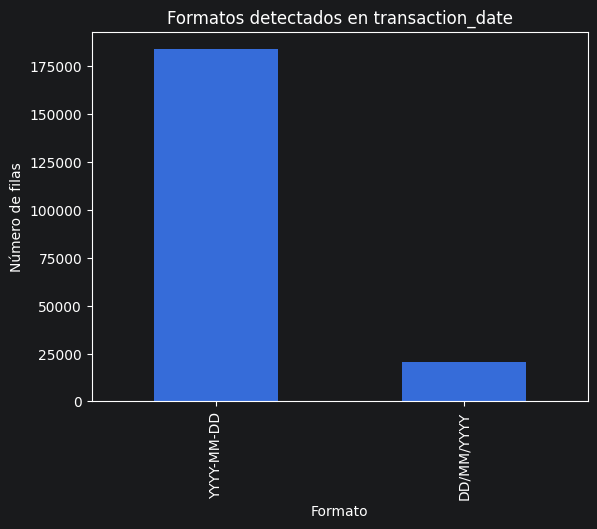

In [12]:
transaction_date_str = df_raw["transaction_date"].astype("string").str.strip()

date_format = pd.Series("other", index=df_raw.index, dtype="string")
date_format[transaction_date_str.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)] = "YYYY-MM-DD"
date_format[transaction_date_str.str.match(r"^\d{2}/\d{2}/\d{4}$", na=False)] = "DD/MM/YYYY"

date_format_counts = date_format.value_counts(dropna=False)

display(date_format_counts.to_frame("count"))

ax = date_format_counts.plot(kind="bar")
ax.set_title("Formatos detectados en transaction_date")
ax.set_xlabel("Formato")
ax.set_ylabel("Número de filas")
plt.show()

In [13]:
date_iso = pd.to_datetime(
    df_raw["transaction_date"],
    format="%Y-%m-%d",
    errors="coerce",
)

date_dmy = pd.to_datetime(
    df_raw["transaction_date"],
    format="%d/%m/%Y",
    errors="coerce",
)

df_eda["transaction_date_parsed"] = date_iso.fillna(date_dmy)

date_parse_failures = (
    df_raw["transaction_date"].notna()
    & df_eda["transaction_date_parsed"].isna()
)

print(f"Transaction date parse failures among non-null values: {date_parse_failures.sum():,}")

display(
    df_eda["transaction_date_parsed"]
    .describe()
    .to_frame("transaction_date_parsed")
)

Transaction date parse failures among non-null values: 0


,transaction_date_parsed
count,204000
mean,2024-12-31 04:29:11.717647104
min,2024-01-01 00:00:00
25%,2024-07-01 00:00:00
50%,2025-01-01 00:00:00
75%,2025-07-01 00:00:00
max,2025-12-31 00:00:00


### Observación

`transaction_date` contiene más de un formato de fecha.

### Implicación

Para evitar perder filas o parsear fechas incorrectamente, usaré una estrategia explícita de dos formatos: primero `YYYY-MM-DD` y después `DD/MM/YYYY`. Esta lógica se trasladará a `load_clean`.

## 8. Coherencia entre `reference_date` y `last_complaint_date`

Según la documentación, `reference_date` representa el snapshot del análisis. Por tanto, reviso si `last_complaint_date` contiene fechas posteriores a ese snapshot.

In [14]:
df_eda["reference_date_parsed"] = pd.to_datetime(
    df_raw["reference_date"],
    errors="coerce"
)

last_complaint_iso = pd.to_datetime(
    df_raw["last_complaint_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

last_complaint_dmy = pd.to_datetime(
    df_raw["last_complaint_date"],
    format="%d/%m/%Y",
    errors="coerce"
)

df_eda["last_complaint_date_parsed"] = last_complaint_iso.fillna(last_complaint_dmy)

print("reference_date unique values:")
display(df_eda["reference_date_parsed"].value_counts(dropna=False).to_frame("count"))

future_complaint_mask = (
    df_eda["last_complaint_date_parsed"].notna()
    & df_eda["reference_date_parsed"].notna()
    & (df_eda["last_complaint_date_parsed"] > df_eda["reference_date_parsed"])
)

future_complaints = future_complaint_mask.sum()

print(
    f"Rows with last_complaint_date > reference_date: "
    f"{future_complaints:,} ({future_complaints / len(df_eda) * 100:.2f}%)"
)

display(
    df_eda.loc[
        future_complaint_mask,
        [
            "merchant_id",
            "transaction_date",
            "reference_date",
            "last_complaint_date",
            "fla_churn90",
        ],
    ].head(10)
)

reference_date unique values:


,count
reference_date_parsed,
2025-09-30,204000


Rows with last_complaint_date > reference_date: 3,535 (1.73%)


,merchant_id,transaction_date,reference_date,last_complaint_date,fla_churn90
13,10008871,2024-08-08,2025-09-30,2025-11-24,1
194,10000589,2025-04-07,2025-09-30,2025-11-12,1
236,10000782,2024-06-02,2025-09-30,2025-10-11,1
354,10007581,2024-06-02,2025-09-30,2025-11-04,1
450,10007853,13/09/2025,2025-09-30,2025-10-25,1
487,10003518,2024-04-26,2025-09-30,2025-10-15,1
598,10002910,2024-01-16,2025-09-30,2025-10-03,1
613,10002910,2025-07-24,2025-09-30,2025-10-03,1
703,10004058,2025-08-15,2025-09-30,2025-11-01,1
772,10008871,2025-11-24,2025-09-30,2025-11-24,1


### Observación

Existen filas donde `last_complaint_date` es posterior a `reference_date`.

### Implicación

Como `reference_date` representa el snapshot del análisis, no usaré `last_complaint_date` directamente como feature predictiva. Si se utiliza, deberá transformarse de forma segura considerando solo fechas anteriores o iguales al snapshot.

## 9. Relación entre `cancellation_reason` y `fla_churn90`

Reviso si la presencia de `cancellation_reason` está distribuida de forma similar entre clases o si aparece asociada casi exclusivamente a una de ellas.

has_cancellation_reason,False,True,All
fla_churn90,,,
0,189637,0,189637
1,1144,13219,14363
All,190781,13219,204000


,pct_with_cancellation_reason
fla_churn90,
0,0.0
1,92.04


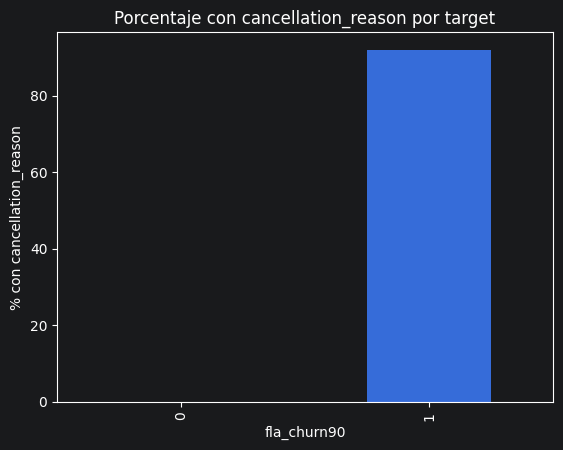

In [15]:
cancellation_flag = (
    df_raw["cancellation_reason"].notna()
    & (df_raw["cancellation_reason"].astype("string").str.strip() != "")
)

cancellation_vs_target = pd.crosstab(
    df_raw["fla_churn90"],
    cancellation_flag,
    rownames=["fla_churn90"],
    colnames=["has_cancellation_reason"],
    margins=True,
)

display(cancellation_vs_target)

cancellation_rate_by_target = (
    cancellation_flag
    .groupby(df_raw["fla_churn90"])
    .mean()
    .mul(100)
    .round(2)
    .rename("pct_with_cancellation_reason")
    .to_frame()
)

display(cancellation_rate_by_target)

ax = cancellation_rate_by_target["pct_with_cancellation_reason"].plot(kind="bar")
ax.set_title("Porcentaje con cancellation_reason por target")
ax.set_xlabel("fla_churn90")
ax.set_ylabel("% con cancellation_reason")
plt.show()

### Observación

`cancellation_reason` aparece fuertemente asociado a la clase positiva de `fla_churn90`.

### Implicación

Aunque esta columna podría mejorar mucho las métricas de un modelo, la trataré como información potencialmente post-evento. Por tanto, no la usaré como feature predictiva en Parte 3 y la reportaré como riesgo de leakage en `quality_report`.

## 10. Duplicados técnicos y duplicados de negocio

Compruebo si hay duplicados por `transaction_id` y también duplicados de negocio ignorando `transaction_id`. Esto es importante porque una transacción reenviada podría tener un nuevo identificador pero representar el mismo evento.

In [16]:
duplicated_transaction_id_rows = df_raw["transaction_id"].duplicated(keep=False).sum()

business_cols = [col for col in df_raw.columns if col != "transaction_id"]

business_duplicate_mask = df_raw.duplicated(
    subset=business_cols,
    keep=False,
)

business_duplicate_extra_rows = df_raw.duplicated(
    subset=business_cols,
    keep="first",
).sum()

duplicate_summary = pd.DataFrame({
    "metric": [
        "duplicated_transaction_id_rows",
        "business_duplicate_rows_excluding_transaction_id",
        "business_duplicate_extra_rows_to_drop",
    ],
    "count": [
        duplicated_transaction_id_rows,
        business_duplicate_mask.sum(),
        business_duplicate_extra_rows,
    ],
})

duplicate_summary["pct_rows"] = (
    duplicate_summary["count"] / len(df_raw) * 100
).round(2)

display(duplicate_summary)

display(
    df_raw.loc[business_duplicate_mask]
    .sort_values(business_cols)
    .head(10)
)

,metric,count,pct_rows
0,duplicated_transaction_id_rows,0,0.00
1,business_duplicate_rows_excluding_transaction_id,8273,4.06
2,business_duplicate_extra_rows_to_drop,4151,2.03


,transaction_id,merchant_id,transaction_date,amount,status,channel,cancellation_reason,reference_date,fla_churn90,last_complaint_date,segment,mcc,dat_process
55564,55565,10000001,2024-03-07,"70,79",denied,tef,NaN,2025-09-30,0,NaN,SMB,5812,2024-03-07
202309,202310,10000001,2024-03-07,"70,79",denied,tef,NaN,2025-09-30,0,NaN,SMB,5812,2024-03-07
46682,46683,10000011,2024-09-07,"159,30",denied,pos,NaN,2025-09-30,0,2025-06-26,SMB,7011,2024-09-07
201806,201807,10000011,2024-09-07,"159,30",denied,pos,NaN,2025-09-30,0,2025-06-26,SMB,7011,2024-09-07
59195,59196,10000013,2025-01-23,"16,12",approved,ecom,NaN,2025-09-30,0,NaN,SMB,5499,2025-01-23
201730,201731,10000013,2025-01-23,"16,12",approved,ecom,NaN,2025-09-30,0,NaN,SMB,5499,2025-01-23
73432,73433,10000016,04/11/2025,"1.270,96",approved,tef,NaN,2025-09-30,0,NaN,SMB,5912,2025-11-04
201146,201147,10000016,04/11/2025,"1.270,96",approved,tef,NaN,2025-09-30,0,NaN,SMB,5912,2025-11-04
191539,191540,10000016,2024-05-17,"24,77",approved,pix,NaN,2025-09-30,0,NaN,SMB,5912,2024-05-17
202774,202775,10000016,2024-05-17,"24,77",approved,pix,NaN,2025-09-30,0,NaN,SMB,5912,2024-05-17


### Observación

No basta con revisar duplicados por `transaction_id`. Existen filas duplicadas a nivel de negocio aunque tengan identificadores distintos.

### Implicación

En `load_clean`, la deduplicación se hará usando columnas de negocio y no únicamente `transaction_id`. Esto evita inflar TPV, número de transacciones y features agregadas.

## 11. Análisis de importes extremos

Reviso la distribución de `amount` después de parsearlo a numérico. En datos de pagos es habitual encontrar una distribución muy asimétrica: muchas operaciones pequeñas y pocas operaciones de importe alto. Por eso no eliminaré outliers automáticamente, sino que primero cuantificaré su magnitud.

In [17]:
amount_quantiles = (
    df_eda["amount_num"]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999, 1.0])
    .rename("amount_num")
    .to_frame()
)

display(amount_quantiles)

,amount_num
0.000,0.53
0.010,5.63
0.050,11.18
0.250,30.59
0.500,63.47
0.750,140.79
0.950,644.814
0.990,2459.1664
0.995,3997.3868
0.999,9585.05152


In [18]:
amount_q1 = df_eda["amount_num"].quantile(0.25)
amount_q3 = df_eda["amount_num"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1
amount_upper_iqr = amount_q3 + 1.5 * amount_iqr

outlier_amount_mask = df_eda["amount_num"] > amount_upper_iqr

outlier_summary = pd.DataFrame({
    "metric": [
        "q1",
        "q3",
        "iqr",
        "upper_bound_q3_1_5_iqr",
        "rows_above_bound",
        "pct_rows_above_bound",
    ],
    "value": [
        amount_q1,
        amount_q3,
        amount_iqr,
        amount_upper_iqr,
        outlier_amount_mask.sum(),
        round(outlier_amount_mask.mean() * 100, 2),
    ],
})

display(outlier_summary)

,metric,value
0,q1,30.59
1,q3,140.79
2,iqr,110.20
3,upper_bound_q3_1_5_iqr,306.09
4,rows_above_bound,21954.00
5,pct_rows_above_bound,11.09


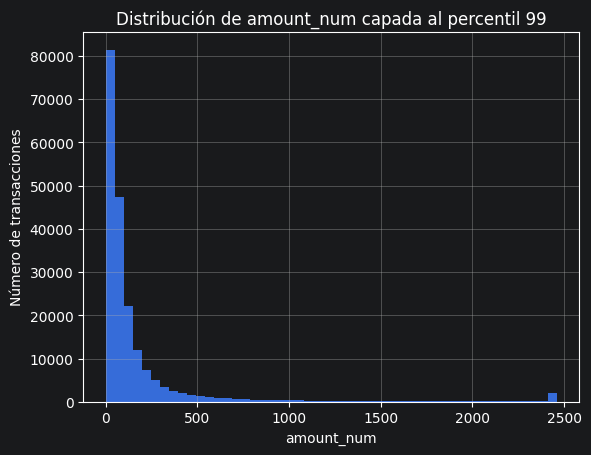

In [19]:
ax = (
    df_eda["amount_num"]
    .dropna()
    .clip(upper=df_eda["amount_num"].quantile(0.99))
    .hist(bins=50)
)

ax.set_title("Distribución de amount_num capada al percentil 99")
ax.set_xlabel("amount_num")
ax.set_ylabel("Número de transacciones")
plt.show()

### Observación

La distribución de `amount` es muy asimétrica: la mayoría de transacciones tienen importes bajos o medios, pero existen operaciones de importe muy alto. No tengo evidencia suficiente para tratarlas automáticamente como errores, especialmente porque en datos de pagos pueden existir transacciones legítimas de alto importe según el tipo de merchant o MCC.

### Implicación

No eliminaré estos valores en la limpieza base. Los conservaré para KPIs si son importes parseables y positivos. Para visualización o modelado, consideraría transformaciones robustas como percentiles, winsorization o `log1p`, pero siempre documentando la decisión.

## 12. Coherencia entre `cancellation_reason` y `status`

Reviso si `cancellation_reason` se comporta como una variable asociada al estado de una transacción concreta o si parece una variable de otro nivel, por ejemplo asociada al merchant o al evento de churn.

In [20]:
cancellation_flag = (
    df_raw["cancellation_reason"].notna()
    & (df_raw["cancellation_reason"].astype("string").str.strip() != "")
)

status_cancel_table = pd.crosstab(
    df_raw["status"],
    cancellation_flag,
    rownames=["status"],
    colnames=["has_cancellation_reason"],
    margins=True,
)

display(status_cancel_table)

has_cancellation_reason,False,True,All
status,,,
approved,167879,11609,179488
denied,19116,1336,20452
reversed,3786,274,4060
All,190781,13219,204000


In [21]:
display(
    df_raw.loc[
        cancellation_flag,
        ["merchant_id", "transaction_id", "transaction_date", "status", "amount", "cancellation_reason", "fla_churn90"]
    ].head(20)
)

,merchant_id,transaction_id,transaction_date,status,amount,cancellation_reason,fla_churn90
13,10008871,14,2024-08-08,approved,NaN,bankruptcy,1
18,10007913,19,2025-02-04,approved,"65,77",high_fees,1
34,10006854,35,2024-09-23,approved,"13,45",competitor_better_terms,1
36,10006380,37,2025-06-05,approved,"18,00",fraud_concerns,1
48,10003663,49,19/02/2024,denied,"68,47",device_problems,1
61,10007590,62,2024-03-20,approved,"80,91",competitor_better_terms,1
99,10002944,100,2024-10-08,approved,"11,90",high_fees,1
139,10000997,140,2024-07-05,denied,"206,76",competitor_better_terms,1
141,10001961,142,2025-10-09,approved,"76,39",high_fees,1
147,10004998,148,2024-11-20,approved,"41,68",competitor_better_terms,1


### Observación

`cancellation_reason` aparece en transacciones con distintos estados, incluyendo transacciones `approved`. Por tanto, no parece representar el resultado operativo de una transacción individual.

Esto sugiere que `cancellation_reason` no describe el estado operativo de una transacción individual, sino que probablemente está asociada a un evento de cancelación/churn a nivel merchant. Dado que además aparece únicamente en casos con `fla_churn90 = 1`, la trataré como información potencialmente post-evento y no la usaré como feature predictiva.

No todos los casos positivos tienen `cancellation_reason`, pero ningún caso negativo la tiene informada.

### Implicación

Trataré `cancellation_reason` como una variable sensible: parece más relacionada con un evento de cancelación/churn a nivel merchant que con la calidad de una transacción concreta. Aunque puede ser útil para análisis descriptivo, no la usaré como feature predictiva.

## 13. Coherencia entre `transaction_date` y `reference_date`

Dado que `reference_date` representa el snapshot del análisis, reviso si existen transacciones posteriores a ese snapshot. Estas transacciones pueden ser válidas para análisis descriptivo general, pero no deberían utilizarse como señales disponibles en el momento del snapshot.

In [22]:
future_tx_mask = (
    df_eda["transaction_date_parsed"].notna()
    & df_eda["reference_date_parsed"].notna()
    & (df_eda["transaction_date_parsed"] > df_eda["reference_date_parsed"])
)

future_tx_summary = pd.DataFrame({
    "metric": [
        "rows_after_reference_date",
        "pct_rows_after_reference_date",
        "min_future_transaction_date",
        "max_future_transaction_date",
    ],
    "value": [
        future_tx_mask.sum(),
        round(future_tx_mask.mean() * 100, 2),
        df_eda.loc[future_tx_mask, "transaction_date_parsed"].min(),
        df_eda.loc[future_tx_mask, "transaction_date_parsed"].max(),
    ],
})

display(future_tx_summary)

display(
    df_eda.loc[
        future_tx_mask,
        ["merchant_id", "transaction_date", "transaction_date_parsed", "reference_date", "fla_churn90", "amount"]
    ].head(10)
)

,metric,value
0,rows_after_reference_date,25587
1,pct_rows_after_reference_date,12.54
2,min_future_transaction_date,2025-10-01 00:00:00
3,max_future_transaction_date,2025-12-31 00:00:00


,merchant_id,transaction_date,transaction_date_parsed,reference_date,fla_churn90,amount
9,10000386,2025-11-07,2025-11-07,2025-09-30,0,"20,17"
40,10004241,2025-12-21,2025-12-21,2025-09-30,0,"42,13"
53,10000443,2025-10-17,2025-10-17,2025-09-30,0,"100,53"
54,10007415,2025-12-02,2025-12-02,2025-09-30,0,"106,13"
57,10001277,2025-11-14,2025-11-14,2025-09-30,0,"68,59"
58,10007299,2025-12-01,2025-12-01,2025-09-30,0,"7,93"
59,10003402,2025-12-30,2025-12-30,2025-09-30,0,"1.933,15"
63,10003258,07/10/2025,2025-10-07,2025-09-30,0,"185,24"
71,10005029,2025-10-11,2025-10-11,2025-09-30,0,"185,41"
72,10008195,2025-12-30,2025-12-30,2025-09-30,0,"31,92"


### Observación

Existen transacciones posteriores a `reference_date`, que según la documentación representa el snapshot del análisis.

### Implicación

Estas transacciones pueden ser útiles para análisis descriptivos del dataset completo, pero no deberían usarse para construir señales predictivas disponibles en el snapshot. Para Parte 3 y para cualquier heurística de pre-churn, filtraré o construiré features usando únicamente información con fecha menor o igual a `reference_date`.

## 14. Valores esperados en columnas categóricas

Reviso los valores reales de columnas categóricas clave. Esto permite detectar categorías inesperadas, diferencias con la documentación o valores que requieran normalización.

In [23]:
for col in ["status", "channel", "segment", "mcc"]:
    print(f"\n=== {col} ===")
    display(
        df_raw[col]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )


=== status ===


,count
status,
approved,179488
denied,20452
reversed,4060



=== channel ===


,count
channel,
pos,111921
ecom,40739
pix,30697
tef,20643



=== segment ===


,count
segment,
SMB,181725
MidMarket,18692
Enterprise,3583



=== mcc ===


,count
mcc,
5732,49846
5499,23848
7995,19984
4789,18192
5912,16744
5311,16589
5411,15216
5812,15169
7011,14528


### Observación

Las columnas categóricas principales contienen un conjunto reducido de valores. En `status` aparecen `approved`, `denied` y `reversed`; en `channel` aparecen `pos`, `ecom`, `pix` y `tef`; en `segment` aparecen `SMB`, `MidMarket` y `Enterprise`. En `mcc` aparecen códigos como `5732`, `5499`, `7995`, `4789`, `5912`, `5311`, `5411`, `5812`, `7011` y `5651`.

Aunque `mcc` puede cargarse como numérico, conceptualmente es un código categórico. Un valor de MCC más alto no significa una magnitud mayor ni una relación ordinal entre categorías. Por tanto, lo trataré como string/categoría en análisis y modelado, no como variable numérica continua.

### Implicación

En la limpieza normalizaré `status` y `channel` para evitar inconsistencias de formato en los cálculos. También validaré en `quality_report` si aparecen valores inesperados en columnas categóricas clave.

Para KPIs, consideraré `approved` como el estado válido para TPV procesado y trataré `denied`/`reversed` como transacciones no aprobadas. Para análisis y modelado, trataré `segment` y `mcc` como variables categóricas.

## 15. Valores nulos de `amount` por estado de transacción

Como `amount` es necesario para calcular TPV, reviso si sus valores ausentes se concentran en algún estado concreto de transacción.

In [24]:
amount_missing_by_status = pd.crosstab(
    df_raw["status"],
    df_eda["amount_num"].isna(),
    rownames=["status"],
    colnames=["amount_is_missing"],
    margins=True,
)

display(amount_missing_by_status)

amount_is_missing,False,True,All
status,,,
approved,174140,5348,179488
denied,19828,624,20452
reversed,3945,115,4060
All,197913,6087,204000


### Observación

Los valores ausentes de `amount` aparecen en distintos estados de transacción, incluyendo transacciones `approved`.

### Implicación

No asumiré que `amount` missing es irrelevante o que solo ocurre en transacciones fallidas. Para KPIs monetarios, las filas sin importe no pueden contribuir al TPV, pero deben reportarse en `quality_report` porque pueden infraestimar volumen.

## 16. Churn por segmento y MCC

Reviso la tasa de churn por variables de contexto del merchant. Esto no implica causalidad, pero ayuda a entender si el riesgo está distribuido de forma homogénea o varía por tipo de comercio.

In [25]:
merchant_base = (
    df_raw
    .sort_values("merchant_id")
    .groupby("merchant_id", as_index=False)
    .agg(
        fla_churn90=("fla_churn90", "first"),
        segment=("segment", "first"),
        mcc=("mcc", "first"),
        n_tx=("transaction_id", "count"),
    )
)

churn_by_segment = (
    merchant_base
    .groupby("segment")
    .agg(
        n_merchants=("merchant_id", "count"),
        churn_rate=("fla_churn90", "mean"),
    )
    .reset_index()
)

churn_by_segment["churn_rate_pct"] = (
    churn_by_segment["churn_rate"] * 100
).round(2)

display(churn_by_segment.sort_values("churn_rate", ascending=False))

,segment,n_merchants,churn_rate,churn_rate_pct
2,SMB,8533,0.094691,9.47
1,MidMarket,1171,0.047822,4.78
0,Enterprise,278,0.032374,3.24


In [26]:
churn_by_mcc = (
    merchant_base
    .groupby("mcc")
    .agg(
        n_merchants=("merchant_id", "count"),
        churn_rate=("fla_churn90", "mean"),
    )
    .reset_index()
)

churn_by_mcc["churn_rate_pct"] = (
    churn_by_mcc["churn_rate"] * 100
).round(2)

display(churn_by_mcc.sort_values("churn_rate", ascending=False))

,mcc,n_merchants,churn_rate,churn_rate_pct
4,5651,971,0.106076,10.61
0,4789,1024,0.100586,10.06
5,5732,1009,0.092170,9.22
7,5912,992,0.091734,9.17
1,5311,1006,0.086481,8.65
9,7995,1020,0.085294,8.53
6,5812,1006,0.084493,8.45
2,5411,1000,0.079000,7.90
8,7011,969,0.076367,7.64
3,5499,985,0.072081,7.21


### Observación

La tasa de churn varía entre segmentos y MCCs cuando se calcula a nivel merchant. Esto sugiere que `segment` y `mcc` pueden aportar señal descriptiva.

### Implicación

Usaría estas variables como categóricas en análisis/modelado, pero no interpretaría sus diferencias como causas del churn. Además, para churn prefiero calcular estas tasas a nivel merchant, no a nivel transacción, para evitar sesgo por volumen transaccional.

## 17. Resumen de hallazgos y decisiones para la implementación

A partir del análisis exploratorio, trasladaré las siguientes decisiones a `src/parte1_pandas.py`:

1. Parsear `amount` explícitamente desde formato BR/ES a numérico.
2. Parsear `transaction_date` con dos formatos: `YYYY-MM-DD` y `DD/MM/YYYY`.
3. Tratar `mcc` como variable categórica/string, no como número continuo.
4. Deduplicar por columnas de negocio, no solo por `transaction_id`.
5. Reportar nulos de `amount` porque afectan directamente al TPV.
6. No eliminar importes extremos automáticamente; conservarlos si son válidos y documentar posibles transformaciones robustas para modelado.
7. No usar `cancellation_reason` como feature predictiva por su asociación fuerte con `fla_churn90` y su posible carácter post-evento.
8. No usar directamente `last_complaint_date` si es posterior a `reference_date`.
9. Para señales predictivas o heurísticas de pre-churn, usar solo información disponible hasta `reference_date`.
10. Calcular análisis de churn a nivel merchant, no solo a nivel fila/transacción.

Estos hallazgos no modifican todavía el dataset original. Sirven para justificar la implementación de `load_clean`, `quality_report`, `monthly_kpis` y `merchants_at_risk` en `src/parte1_pandas.py`.